In [2]:
import itertools

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy import linalg
import pandas as pd

from sklearn import mixture

In [3]:
# import os
# for sub in np.arange(7,19,0.1):
#     os.mkdir('/data/project_unTimely_light_curve/results/GMM_clustering/%.1f-%.1f'%(sub,sub+0.1))

In [ ]:
def GMM_for_one_bin(band,sub,upper):
    dpgmm = mixture.BayesianGaussianMixture(
        n_components=3,
        covariance_type="full",
        weight_concentration_prior=0.1,
        weight_concentration_prior_type="dirichlet_process",
        mean_precision_prior=1e-2,
        covariance_prior=1e0 * np.eye(13),
        init_params="random",
        max_iter=100,
        random_state=2,
    )
    table = pd.read_csv('/data/project_unTimely_light_curve/total_catalogues/binned_new_var_paras/%.1f-%.1f/%s_matched_with_corelation.csv'%(sub,upper,band)) 
    print(len(table))
    table = table[table['corelation']>0.8]
    print(len(table))
    table = table[['ra','dec','Mean','long_name','id_in_matched',
       'chi_squre', 'rcs', 'w_sigma', 'MAD', 'IQR', 'RmStat', 'Nev', 'p2pv',
       'L1_acr', 'Stetson_J', 'Stetson_K', 'yita']]
    table.replace([np.inf, -np.inf], np.nan, inplace=True)
    table.dropna(inplace=True)
    print(len(table))
    X = np.array(table[['Mean',
       'chi_squre', 'rcs', 'w_sigma', 'MAD', 'IQR', 'RmStat', 'Nev', 'p2pv',
       'L1_acr', 'Stetson_J', 'Stetson_K', 'yita']])
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    scaler.fit(X)
    X = scaler.transform(X)
    dpgmm = dpgmm.fit(X)
    Y = dpgmm.predict(X)

    result_lists = []
    for i in range(3):
        result_lists.append([])
    ras = np.array(table['ra'])
    decs = np.array(table['dec'])
    ids = np.array(table['id_in_matched'])
    names = np.array(table['long_name'])
    # for (i, label) in enumerate(Y):
    for (i, label) in enumerate(Y):
        ra = ras[i]
        dec = decs[i]
        index = ids[i]
        name = names[i]
        if label == 0:
            result_lists[0].append((ra, dec, index, name))
        elif label == 1:
            result_lists[1].append((ra, dec, index, name))
        elif label == 2:
            result_lists[2].append((ra, dec, index, name))
        else:
            print("error")
    for i in range(3):
        df = pd.DataFrame(result_lists[i])
        df.to_csv('/data/project_unTimely_light_curve/results/GMM_clustering/%.1f-%.1f/%s_table%d'%(sub,upper,band,i),
                index=False,header=['ra','dec','id_in_matched','long_name'])

In [ ]:
for sub in np.arange(7,19,0.1):
    print(sub)
    GMM_for_one_bin('w1',sub,sub+0.1)
    GMM_for_one_bin('w2',sub,sub+0.1)

In [13]:
dpgmm = mixture.BayesianGaussianMixture(
    n_components=3,
    covariance_type="full",
    weight_concentration_prior=0.1,
    weight_concentration_prior_type="dirichlet_process",
    mean_precision_prior=1e-2,
    covariance_prior=1e0 * np.eye(13),
    init_params="random",
    max_iter=100,
    random_state=2,
)

In [25]:
import pandas as pd
sub = 15.0
band = 'w2'
table = pd.read_csv('/data/project_unTimely_light_curve/total_catalogues/binned_new_var_paras/%.1f-%.1f/%s_total_paras.csv'%(sub,sub+0.1,band))
print(len(table))

11839735


In [6]:
# table_all = table
# table = table_all[15000000:30957417]

In [124]:
print(table.columns)
print(len(table))

Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'long_name',
       'id_in_matched', 'ra', 'dec', 'Mean', 'chi_squre', 'rcs', 'w_sigma',
       'MAD', 'IQR', 'RmStat', 'Nev', 'p2pv', 'L1_acr', 'Stetson_J',
       'Stetson_K', 'yita', 'kai_squre', 'reduced_chi_Square'],
      dtype='object')
2826625


In [ ]:
table = table[['ra','dec','Mean','long_name','id_in_matched',
       'chi_squre', 'rcs', 'w_sigma', 'MAD', 'IQR', 'RmStat', 'Nev', 'p2pv',
       'L1_acr', 'Stetson_J', 'Stetson_K', 'yita']]
table.replace([np.inf, -np.inf], np.nan, inplace=True)
table.dropna(inplace=True)
print(len(table))

10316903


In [ ]:
X = np.array(table[['Mean',
       'chi_squre', 'rcs', 'w_sigma', 'MAD', 'IQR', 'RmStat', 'Nev', 'p2pv',
       'L1_acr', 'Stetson_J', 'Stetson_K', 'yita']])
np.nanmax(X)


3466023.188893361

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)
np.nanmax(X)

2526.8316654294363

In [ ]:
dpgmm = dpgmm.fit(X)

/home/kangzihan/.local/lib/python3.10/site-packages/sklearn/mixture/_base.py:270: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


(array([7149058.,       0.,       0.,       0.,       0., 2420383.,
              0.,       0.,       0.,  747462.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

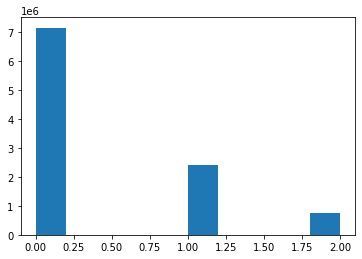

In [15]:
Y = dpgmm.predict(X)
plt.hist(Y)

In [17]:
from collections import Counter
count = Counter(Y)
print(count)
print(sum(count.values()))

Counter({0: 7149058, 1: 2420383, 2: 747462})
10316903


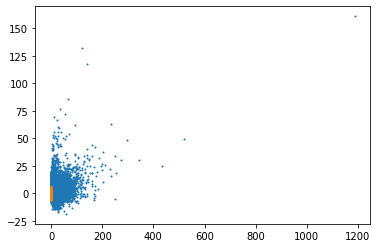

In [16]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_2dim = pca.fit_transform(X)
plt.scatter(X_2dim[:,0],X_2dim[:,1],s=1)

plt.scatter( list((x for (i,x) in enumerate(X_2dim[:,0]) if Y[i] == 0)),
             list((x for (i,x) in enumerate(X_2dim[:,1]) if Y[i] == 0)),
             s=1)

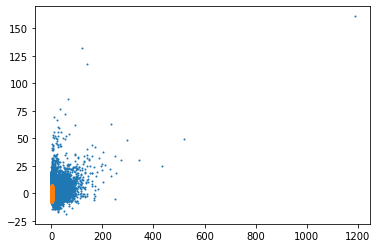

In [18]:
plt.scatter(X_2dim[:,0],X_2dim[:,1],s=1)

plt.scatter( list((x for (i,x) in enumerate(X_2dim[:,0]) if Y[i] == 1)),
             list((x for (i,x) in enumerate(X_2dim[:,1]) if Y[i] == 1)),
             s=1)

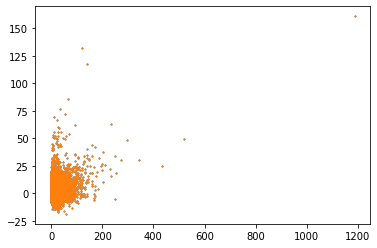

In [19]:
plt.scatter(X_2dim[:,0],X_2dim[:,1],s=1)

plt.scatter( list((x for (i,x) in enumerate(X_2dim[:,0]) if Y[i] == 2)),
             list((x for (i,x) in enumerate(X_2dim[:,1]) if Y[i] == 2)),
             s=1)

In [21]:
Y_prob = dpgmm.predict_proba(X)
print(Y_prob.shape)

(10316903, 3)


In [203]:
Y_prob[:,0]

array([6.01739324e-06, 6.95556617e-06, 3.92149970e-06, ...,
       1.32472599e-04, 9.13538039e-07, 2.86074538e-02])

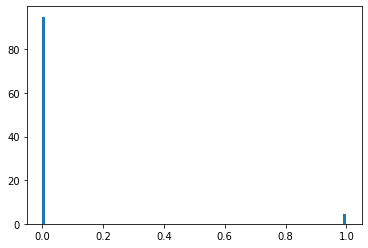

In [207]:
plt.hist(Y_prob[:,1],bins=100,density=True)
plt.show()

In [22]:
result_lists = []
for i in range(3):
    result_lists.append([])
ras = np.array(table['ra'])
decs = np.array(table['dec'])
ids = np.array(table['id_in_matched'])
names = np.array(table['long_name'])
# for (i, label) in enumerate(Y):
for ((i, label), prob ) in zip(enumerate(Y),Y_prob):
    ra = ras[i]
    dec = decs[i]
    index = ids[i]
    name = names[i]
    if label == 0:
        result_lists[0].append((ra, dec, index, name))
    elif label == 1:
        result_lists[1].append((ra, dec, index, name))
    elif label == 2:
        result_lists[2].append((ra, dec, index, name))
    else:
        print("error")

In [23]:
for i in range(3):
    df = pd.DataFrame(result_lists[i])
    df.to_csv(f"./results/clustering_stand_3result_sub{sub}_{band}_{i}.csv",
              index=False,header=['ra','dec','id_in_matched','long_name'])


In [141]:
X_var = []
id_list = []
for i,y in enumerate(Y):
    if y == 0:
        X_var.append(X[i])
        id_list.append(i)

X_var = np.array(X_var)
print(len(X_var))
print(X_var.shape)
print(X_var[0])


278499
(278499, 13)
[  1.27066765   1.38899184   5.03063483   6.33159152  11.35267064
   8.92500967  12.09557687   1.13405513   4.35212247  -1.53140619
 -11.05294698   1.32443935   1.63405297]


(array([218403.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,  60096.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

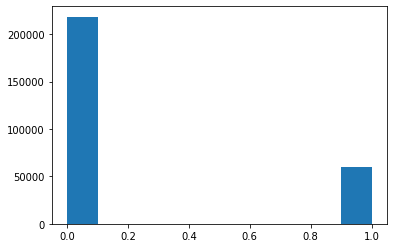

In [142]:
dpgmm_var = mixture.BayesianGaussianMixture(
    n_components=2,
    covariance_type="full",
    weight_concentration_prior=1e-2,
    weight_concentration_prior_type="dirichlet_process",
    mean_precision_prior=1e-2,
    covariance_prior=1e0 * np.eye(13),
    init_params="random",
    max_iter=100,
    random_state=2,
)
dpgmm_var.fit(X_var)

Y_var = dpgmm_var.predict(X_var)

plt.hist(Y_var)


In [143]:
result_lists = []
for i in range(2):
    result_lists.append([])
ras = np.array(table['ra'])
decs = np.array(table['dec'])
# ids = np.array(table['id_in_matched'])
for i, label in zip(id_list, Y_var):
    ra = ras[i]
    dec = decs[i]
    # index = ids[i]
    if label == 0:
        result_lists[0].append((ra, dec))
    elif label == 1:
        result_lists[1].append((ra, dec))
    # elif label == 2:
    #     result_lists[2].append((ra, dec))
    # elif label == 3:      
    #     result_lists[3].append((ra, dec)) 
    else:
        print("error")

In [144]:
for i in range(2):
    df = pd.DataFrame(result_lists[i])
    df.to_csv(f"./results/var_light_stand_2result_w1_sub13_{i}.csv")


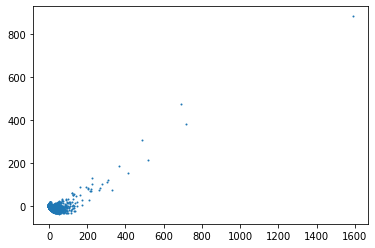

In [145]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_var_2dim = pca.fit_transform(X_var,X_var)
plt.scatter(X_var_2dim[:,0],X_var_2dim[:,1],s=1)


In [1]:
from mpl_toolkits.mplot3d import Axes3D
pca = PCA(n_components=3)
X_var_3dim = pca.fit_transform(X_var,X_var)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
X_var_3dim_subset0 = X_var_3dim[Y_var==0]
X_var_3dim_subset1 = X_var_3dim[Y_var==1]
X_var_3dim_subset2 = X_var_3dim[Y_var==2]

# ax.scatter(X_var_3dim[:,0], X_var_3dim[:,1], X_var_3dim[:,2] ,cmap='rainbow',s=1)
ax.scatter(X_var_3dim_subset2[:,0], 
           X_var_3dim_subset2[:,1],
             X_var_3dim_subset2[:,2] ,cmap='rainbow',s=1)
# ax.scatter(X_var_3dim_subset1[:,0], 
#            X_var_3dim_subset1[:,1],
#              X_var_3dim_subset1[:,2] ,cmap='rainbow',s=1,alpha=0.5)

NameError: name 'PCA' is not defined

In [18]:
print(len(Y))

15421630
